In [18]:
import pandas as pd
import matplotlib.pyplot as plt

file = pd.read_csv("data/train.csv")
train = file.copy()

In [19]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [28]:
categorical_columns = ["Survived", "Pclass", "Sex", "Cabin", "Embarked"]
for col in categorical_columns:
    print(train[col].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


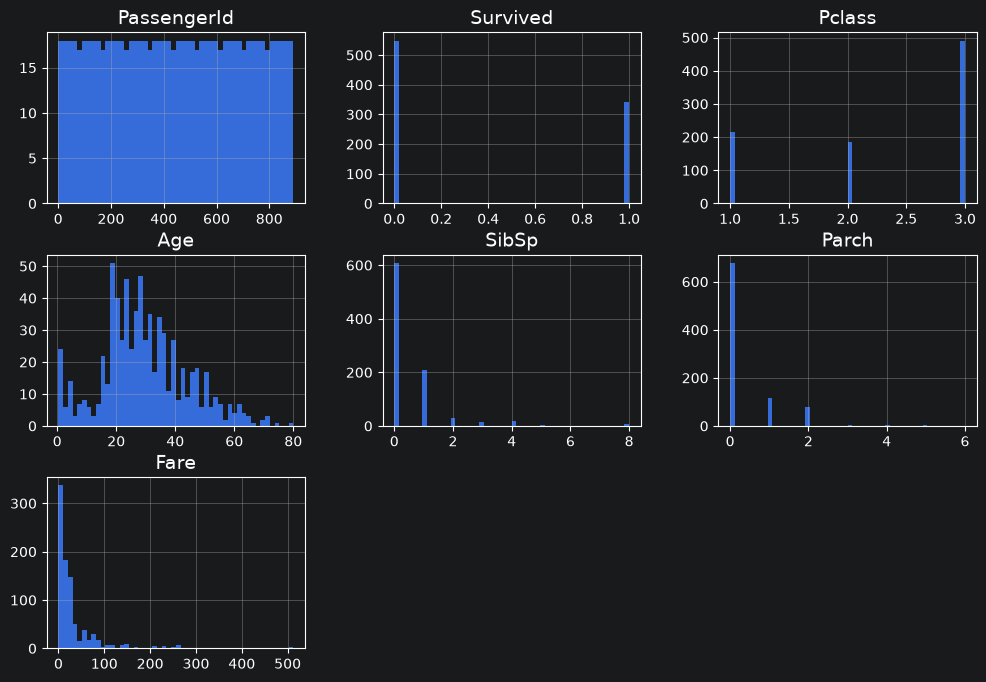

In [23]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
train.hist(bins=50, figsize=(12, 8))
plt.show()


In [32]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

age_category = pd.cut(
    test["Age"],
    bins=[0, 20, 40, 60],
    labels=[1, 2, 3]
)
test["age_category"] = age_category
print(test.head())

strat_test, strat_train = train_test_split(
    test,
    test_size=0.2,
    stratify=test["age_category"],
    random_state=42
)

fig, ax = plt.subplots(2,1)
strat_test["Age"].hist(ax=ax[0])
strat_train["Age"].hist(ax=ax[1])
plt.show()

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked age_category  
0  34.5      0      0   330911   7.8292   NaN        Q            2  
1  47.0      1      0   363272   7.0000   NaN        S            3  
2  62.0      0      0   240276   9.6875   NaN        Q          NaN  
3  27.0      0      0   315154   8.6625   NaN        S            2  
4  22.0      1      1  3101298  12.2875   NaN        S            2  


ValueError: Input y contains NaN.

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


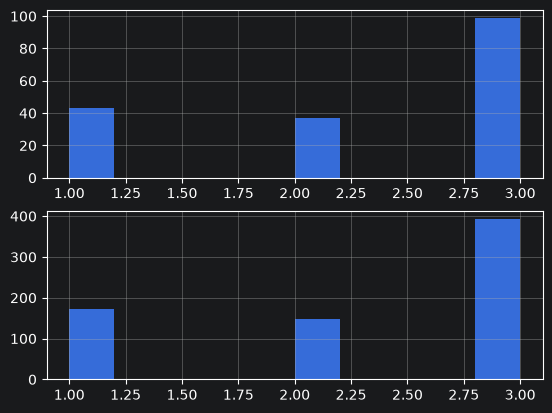

In [41]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print(train.columns)

strat_train, strat_test = train_test_split(
    train,
    test_size=0.2,
    stratify=train["Pclass"],
    random_state=42
)

fig, ax = plt.subplots(2,1)
strat_test["Pclass"].hist(ax=ax[0])
strat_train["Pclass"].hist(ax=ax[1])
plt.show()

In [42]:
corr_matrix = strat_test.corr(numeric_only=True)
print(corr_matrix)
corr_matrix["Survived"]

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.059146 -0.110125 -0.051631 -0.097879 -0.127838   
Survived       -0.059146  1.000000 -0.357572 -0.094320  0.053315  0.169437   
Pclass         -0.110125 -0.357572  1.000000 -0.317730  0.102858  0.039263   
Age            -0.051631 -0.094320 -0.317730  1.000000 -0.271979 -0.149378   
SibSp          -0.097879  0.053315  0.102858 -0.271979  1.000000  0.453361   
Parch          -0.127838  0.169437  0.039263 -0.149378  0.453361  1.000000   
Fare            0.023201  0.280490 -0.492103  0.092336  0.114506  0.126798   

                 Fare  
PassengerId  0.023201  
Survived     0.280490  
Pclass      -0.492103  
Age          0.092336  
SibSp        0.114506  
Parch        0.126798  
Fare         1.000000  


PassengerId   -0.059146
Survived       1.000000
Pclass        -0.357572
Age           -0.094320
SibSp          0.053315
Parch          0.169437
Fare           0.280490
Name: Survived, dtype: float64